In [119]:
import os
import datetime

import torch
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.nn import functional as F
from torchvision.utils import save_image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


In [120]:
RESULTS_PATH = "./results"

LOAD_MODEL = False
LOAD_MODEL_DIR = "ConvVAE_1"
CHAMPION_MODEL_NAME = "champion"

IMG_WIDTH_HEIGHT = 64
DISENTANGLEMENT_RANGE = [-4, 4]
DISENTANGLEMENT_STEPS = 10

hyperparameters = {
    "device": 'cuda' if torch.cuda.is_available() else 'cpu',
    "train_val_split": 0.8,
    
    "lr": 1e-3,
    "batch_size": 128,
    "num_epochs": 1000,
    "latent_dim": 5,
    
    "log_interval": 100,
    
    "early_stopping_rounds": 5,
    "early_stopping_min_delta": 1e-2,
    
    "beta": 1,
}

print(f"Using device: {hyperparameters['device']}")

Using device: cuda


# Loading Data

In [121]:
dataset_zip = np.load('dsprites_64x64.npz')
imgs = dataset_zip['imgs']
imgs_shuffled = imgs[np.random.permutation(imgs.shape[0])]

# Splitting
split = int(hyperparameters['train_val_split'] * imgs_shuffled.shape[0])
train_imgs = imgs_shuffled[:split]
val_imgs  = imgs_shuffled[split:]

In [122]:
class DSpritesDataset(Dataset):
    def __init__(self, imgs):
        # imgs: numpy array (N, 64, 64)
        self.imgs = torch.from_numpy(imgs).float()  # to float32
        self.imgs = self.imgs.unsqueeze(1)  # (N, 1, 64, 64) → add channel dim

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        return self.imgs[idx]

In [123]:
train_loader = DataLoader(DSpritesDataset(train_imgs), batch_size=hyperparameters['batch_size'])
val_loader = DataLoader(DSpritesDataset(val_imgs), batch_size=hyperparameters['batch_size'])

# Data Exploration

In [124]:
def show_images_grid(imgs_, num_images=25):
  ncols = int(np.ceil(num_images**0.5))
  nrows = int(np.ceil(num_images / ncols))
  _, axes = plt.subplots(ncols, nrows, figsize=(nrows * 3, ncols * 3))
  axes = axes.flatten()

  for ax_i, ax in enumerate(axes):
    if ax_i < num_images:
      ax.imshow(imgs_[ax_i], cmap='Greys_r',  interpolation='nearest')
      ax.set_xticks([])
      ax.set_yticks([])
    else:
      ax.axis('off')

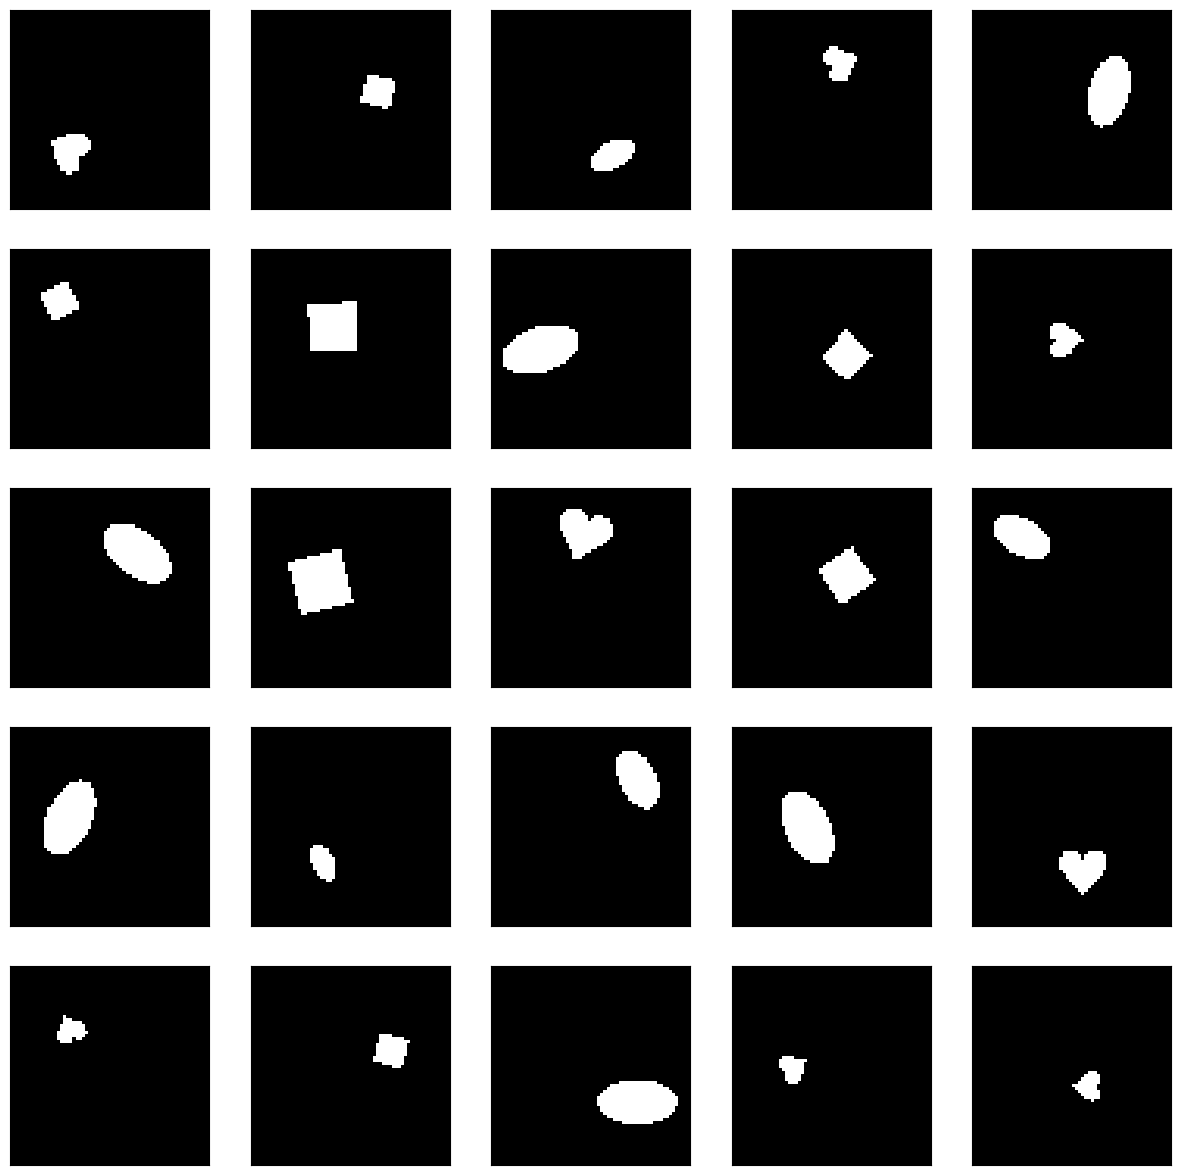

In [125]:
# Get a batch of images
dataiter = iter(train_loader)
images = next(dataiter)

show_images_grid(images.squeeze(1))

# Model

In [126]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(IMG_WIDTH_HEIGHT**2, 400)
        self.fc21 = nn.Linear(400, hyperparameters['latent_dim'])
        self.fc22 = nn.Linear(400, hyperparameters['latent_dim'])
        self.fc3 = nn.Linear(hyperparameters['latent_dim'], 400)
        self.fc4 = nn.Linear(400, IMG_WIDTH_HEIGHT**2)

    def encode(self, x):
        h1 = F.relu(self.fc1(x.view(-1, IMG_WIDTH_HEIGHT**2)))
        return self.fc21(h1), self.fc22(h1) # return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x) # shape: [batch_size, IMG_WIDTH_HEIGHT**2]
        z = self.reparameterize(mu, logvar) # shape: [batch_size, hyperparameters['latent_dim']]
        return self.decode(z), mu, logvar

In [127]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # self.encoder = nn.Sequential(
        #     nn.Conv2d(1, 32, 4, 2, 1),  # 64x64 → 32x32
        #     nn.ReLU(),
        #     nn.Conv2d(32, 64, 4, 2, 1), # 32x32 → 16x16
        #     nn.ReLU(),
        #     nn.Flatten()
        # )
        self.conv1 = nn.Conv2d(1, 32, 4, 2, 1)   # [B, 1, 64, 64] → [B, 32, 32, 32]
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)  # [B, 32, 32, 32] → [B, 64, 16, 16]
        self.flatten = nn.Flatten()

        self.fc_mu = nn.Linear(64 * 16 * 16, latent_dim)
        self.fc_logvar = nn.Linear(64 * 16 * 16, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, 64 * 16 * 16)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Sigmoid()
        )
        self.convtran1 = nn.ConvTranspose2d(64, 32, 4, 2, 1)  
        self.convtran2 = nn.ConvTranspose2d(32, 1, 4, 2, 1)

    def encode(self, x):
        # h = self.encoder(x)
        h = F.relu(self.conv1(x))
        # print(f"after first conv layer shape: {h.shape}")
        h = F.relu(self.conv2(h))
        # print(f"After second conv layer shape: {h.shape}")
        h = self.flatten(h)
        # print(f"Flattened shape: {h.shape}")
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 64, 16, 16)
        h = F.relu(self.convtran1(h))
        # print(f"After first transposed conv layer shape: {h.shape}")
        h = F.sigmoid(self.convtran2(h))
        # print(f"After second transposed conv layer shape: {h.shape}")
        return h
        # return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        # print(f"Mu shape: {mu.shape}, Logvar shape: {logvar.shape}")
        z = self.reparameterize(mu, logvar)
        # print(f"Z shape: {z.shape}")
        return self.decode(z), mu, logvar


In [128]:
# model = VAE().to(hyperparameters['device'])
model = ConvVAE(hyperparameters['latent_dim']).to(hyperparameters['device'])
optimizer = optim.Adam(model.parameters(), lr=hyperparameters['lr'])

# Training functions

In [129]:
# Reconstruction + KL divergence losses summed over all elements and batch
def loss_function(recon_x, x, mu, logvar):
    # BCE = F.binary_cross_entropy(recon_x, x.view(-1, IMG_WIDTH_HEIGHT**2), reduction='sum')
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # see Appendix B from VAE paper:
    # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    # https://arxiv.org/abs/1312.6114
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) # -0.5 since we use logvar instead of sigma^2

    return BCE + hyperparameters['beta'] * KLD, BCE, hyperparameters['beta'] * KLD

def train(epoch):
    model.train()
    train_loss_total= train_bce_loss_total = train_kld_loss_total = 0
    for batch_idx, (data) in enumerate(train_loader): # (data, _) if label is present
        data = data.to(hyperparameters['device'])
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        # print(f"Reconstructed batch shape: {recon_batch.shape}, Data shape: {data.shape}")
        loss, bce_loss, kld_loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss_total += loss.item()
        train_bce_loss_total += bce_loss.item()
        train_kld_loss_total += kld_loss.item()
        optimizer.step()
        
        # Optional logging after certain log_interval
        # if batch_idx % hyperparameters['log_interval'] == 0:
        #     print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
        #         epoch, batch_idx * len(data), len(train_loader.dataset),
        #         100. * batch_idx / len(train_loader),
        #         loss.item() / len(data)))


    print('====> Epoch: {} Average train loss: {:.4f}'.format(
          epoch, train_loss_total / len(train_loader.dataset)))
    
    return train_bce_loss_total / len(train_loader.dataset), train_kld_loss_total / len(train_loader.dataset)


def validate(epoch, result_save_path):
    model.eval()
    val_loss_total = val_bce_loss_total = val_kld_loss_total = 0
    with torch.no_grad():
        for i, (data) in enumerate(val_loader): 
            data = data.to(hyperparameters['device'])
            recon_batch, mu, logvar = model(data)
            loss, bce_loss, kld_loss = loss_function(recon_batch, data, mu, logvar)
            val_loss_total += loss.item()
            val_bce_loss_total += bce_loss.item()
            val_kld_loss_total += kld_loss.item()
            if i == 0:
                n = min(data.size(0), 8)
                comparison = torch.cat([data[:n], recon_batch.view(hyperparameters['batch_size'], 1, IMG_WIDTH_HEIGHT, IMG_WIDTH_HEIGHT)[:n]])
                save_image(comparison.cpu(), os.path.join(result_save_path, f"reconstruction_{str(epoch)}.png"), nrow=n)

    val_loss_total /= len(val_loader.dataset)
    print('====> Epoch: {} Average validation loss: {:.4f}'.format(epoch, val_loss_total))

    return val_bce_loss_total / len(val_loader.dataset), val_kld_loss_total / len(val_loader.dataset)

# Training

In [130]:
def save_model(model, path):
    torch.save(model.state_dict(), path)

def load_model(model, path):
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=hyperparameters['device']))
        print(f"Model loaded from {path}")
        return model
    else:
        print(f"Model file {path} does not exist.")

In [131]:
result_save_path = os.path.join(RESULTS_PATH, str(datetime.datetime.now()))
if not os.path.exists(result_save_path):
    os.makedirs(result_save_path)

train_bce_loss = []
train_kld_loss = []
val_bce_loss = []
val_kld_loss = []
no_epochs_no_improvement = 0
best_val_loss = np.inf

for epoch in range(1, hyperparameters['num_epochs'] + 1):
    train_losses = train(epoch)
    train_bce_loss.append(train_losses[0])
    train_kld_loss.append(train_losses[1])

    val_losses = validate(epoch, result_save_path)
    val_bce_loss.append(val_losses[0])
    val_kld_loss.append(val_losses[1])
    val_loss = val_losses[0] + val_losses[1]

    with torch.no_grad():
        sample = torch.randn(64, hyperparameters['latent_dim']).to(hyperparameters['device'])
        sample = model.decode(sample).cpu()
        save_image(sample.view(64, 1, IMG_WIDTH_HEIGHT, IMG_WIDTH_HEIGHT), os.path.join(result_save_path, f"sample_{str(epoch)}.png"))
    
    # early stopping:
    if best_val_loss - val_loss > hyperparameters['early_stopping_min_delta']: # only when there is a real improvement
        save_model(model, os.path.join(result_save_path, f"{CHAMPION_MODEL_NAME}.pth"))
        no_epochs_no_improvement = 0
        best_val_loss = val_loss
    else:
        no_epochs_no_improvement += 1
        print(f"No improvement for {no_epochs_no_improvement} epochs.")
        if no_epochs_no_improvement >= hyperparameters['early_stopping_rounds']:
            print(f"No improvement for {no_epochs_no_improvement} epochs. Aborted training due to early stopping.")
            break

====> Epoch: 1 Average train loss: 135.4499
====> Epoch: 1 Average validation loss: 104.7220
====> Epoch: 2 Average train loss: 97.4593
====> Epoch: 2 Average validation loss: 93.7047
====> Epoch: 3 Average train loss: 91.8991
====> Epoch: 3 Average validation loss: 90.5193
====> Epoch: 4 Average train loss: 89.7467
====> Epoch: 4 Average validation loss: 89.1891
====> Epoch: 5 Average train loss: 88.1231
====> Epoch: 5 Average validation loss: 86.9531
====> Epoch: 6 Average train loss: 86.3707
====> Epoch: 6 Average validation loss: 85.2704
====> Epoch: 7 Average train loss: 84.5232
====> Epoch: 7 Average validation loss: 83.7025
====> Epoch: 8 Average train loss: 82.8211
====> Epoch: 8 Average validation loss: 82.4344
====> Epoch: 9 Average train loss: 81.3197
====> Epoch: 9 Average validation loss: 80.9286
====> Epoch: 10 Average train loss: 80.1065
====> Epoch: 10 Average validation loss: 79.5494
====> Epoch: 11 Average train loss: 79.1252
====> Epoch: 11 Average validation loss: 7

KeyboardInterrupt: 

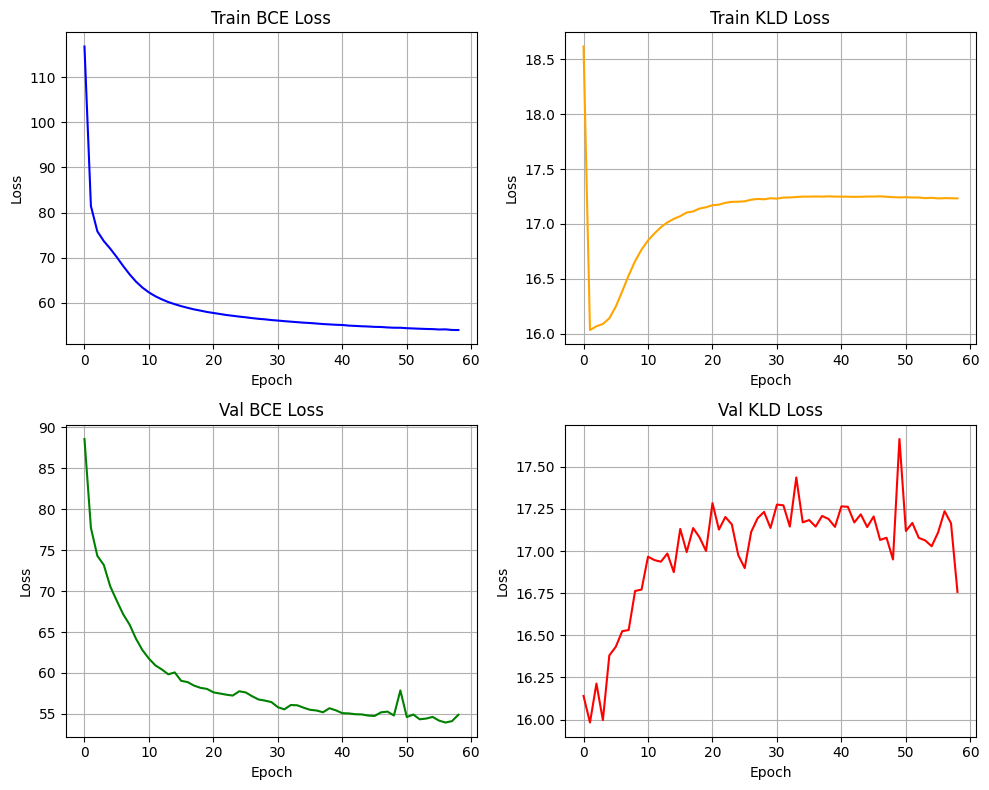

In [132]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
epochs = list(range(len(train_bce_loss)))

# 1: Train BCE
axs[0, 0].plot(epochs, train_bce_loss, label='Train BCE', color='blue')
axs[0, 0].set_title('Train BCE Loss')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].grid(True)

# 2: Train KLD
axs[0, 1].plot(epochs, train_kld_loss, label='Train KLD', color='orange')
axs[0, 1].set_title('Train KLD Loss')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].grid(True)

# 3: Val BCE
axs[1, 0].plot(epochs, val_bce_loss, label='Val BCE', color='green')
axs[1, 0].set_title('Val BCE Loss')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].grid(True)

# 4: Val KLD
axs[1, 1].plot(epochs, val_kld_loss, label='Val KLD', color='red')
axs[1, 1].set_title('Val KLD Loss')
axs[1, 1].set_xlabel('Epoch')
axs[1, 1].set_ylabel('Loss')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Visualization

Not loading a model, using the trained model from the current run.


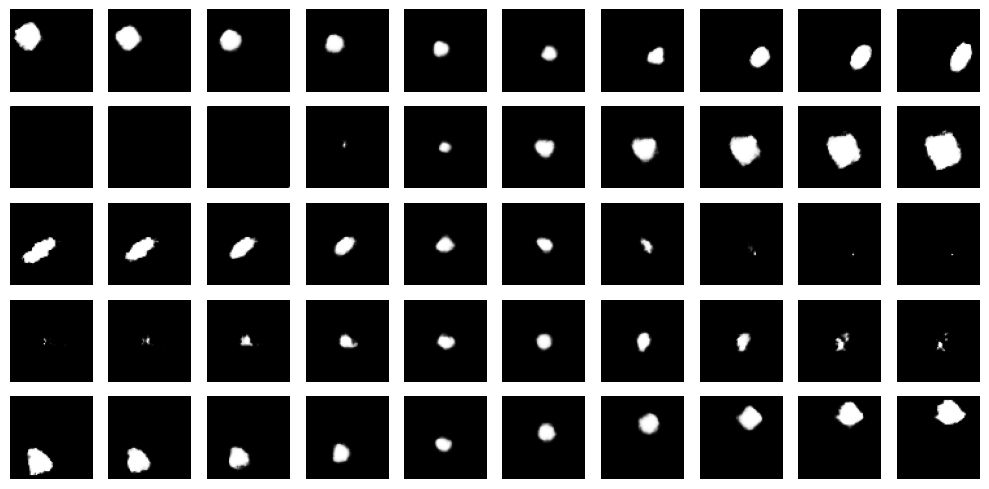

In [133]:
if LOAD_MODEL:
    model = load_model(ConvVAE(hyperparameters['latent_dim']), os.path.join(RESULTS_PATH, LOAD_MODEL_DIR, f"{CHAMPION_MODEL_NAME}.pth")).to(hyperparameters['device'])
else:
    print("Not loading a model, using the trained model from the current run.")

imgs = []
with torch.no_grad():
    z = torch.zeros(hyperparameters['latent_dim'])
    for z_param in range(hyperparameters['latent_dim']):
        row_imgs = []
        for val in torch.linspace(DISENTANGLEMENT_RANGE[0], DISENTANGLEMENT_RANGE[1], DISENTANGLEMENT_STEPS): # tensor with DISENTANGLEMENT_STEPS values ranging from DISENTANGLEMENT_RANGE[0] to DISENTANGLEMENT_RANGE[1]
            z_copy = z.clone().to(hyperparameters['device']) 
            z_copy[z_param] = val  # nur eine Dimension ändern
            img = model.decode(z_copy.unsqueeze(0)) # add batch dimension
            row_imgs.append(img.view(IMG_WIDTH_HEIGHT, IMG_WIDTH_HEIGHT).cpu().numpy()) 
        imgs.append(row_imgs)
        

# Plot
fig, axes = plt.subplots(nrows=hyperparameters['latent_dim'], ncols=DISENTANGLEMENT_STEPS, figsize=(DISENTANGLEMENT_STEPS, hyperparameters['latent_dim']))

for dim in range(hyperparameters['latent_dim']):
    for step in range(DISENTANGLEMENT_STEPS):
        if hyperparameters['latent_dim'] != 1:
            ax = axes[dim, step]
            ax.imshow(imgs[dim][step], cmap='gray')
        else: 
            ax = axes[step]
            ax.imshow(imgs[dim][step], cmap='gray')
        ax.axis('off')

plt.tight_layout()
plt.show()

# Experimenting

In [ ]:
torch.linspace(DISENTANGLEMENT_RANGE[0], DISENTANGLEMENT_RANGE[1], DISENTANGLEMENT_STEPS)

tensor([-4.0000, -3.1111, -2.2222, -1.3333, -0.4444,  0.4444,  1.3333,  2.2222,
         3.1111,  4.0000])

In [ ]:

# z_test = torch.rand([-0.4, 2.0, -2.0, 2.0, -0.8, -2.0, -1.4, 2.0, 1.8, 0.8]).to(hyperparameters['device'])
# img = model.decode(z_copy.unsqueeze(0))
# img = img.view(IMG_WIDTH_HEIGHT, IMG_WIDTH_HEIGHT).detach().cpu().numpy()
# plt.imshow(img, cmap='gray')
# plt.axis('off')
# plt.show()